## Exploratory Data Analysis (EXIST 2026 Dataset)

This notebook explores the EXIST 2026 Dataset that focuses on multimedia formats: images (memes) and videos (TikToks). The main focus of the Exist Task is sexism identification.

In [1]:
#Libraries
import json
from pathlib import Path
from collections import Counter
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

os.chdir("C:/Users/diego/Desktop/Master Neuro/M2/Internship_Valencia/multimodal-exist")

In [2]:
#Path to the data
DATA_DIR = os.path.join("data", "memes", "training")
IMAGES_DIR = os.path.join(DATA_DIR, "memes")

## 1. Memes

In [3]:
#Load the data 
#Read the JSON file containing the training data
with open(os.path.join(DATA_DIR, "EXIST2026_training.json"), "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Convert the raw data into a list of records
records = []
for key, item in raw_data.items():
    row = item.copy()
    records.append(row)

#Dataframe creation
df = pd.DataFrame(records)
print("Shape:", df.shape)
df.head()


Shape: (3984, 17)


,id_EXIST,lang,text,meme,path_memes,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,sensorial,labels_task2_1,labels_task2_2,labels_task2_3,split
0,110887,es,A VECES QUISIERAIR/ALZUMBA www.facebook.com/OiesamamadaOficial www.facebook.com/Ofesamamadaoficial 130 PEROVEOQUE LAS QUE VAN SIGUEN IGUAL DE GORDAS-Y-SE ME PASA,110887.jpeg,memes/110887.jpeg,6,"[Annotator_193, Annotator_194, Annotator_195, Annotator_196, Annotator_197, Annotator_198]","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Multiracial, White or Caucasian, White or Caucasian, Hispano or Latino, Hispano or Latino]","[High school degree or equivalent, Master’s degree, Bachelor’s degree, Master’s degree, Less than high school diploma, High school degree or equivalent]","[Sweden, United States, Spain, Portugal, Spain, Mexico]","{'users': ['ES1', 'ES2', 'ES3'], 'modalities': {'ET': {'by_user': {'ES2': {'reaction_time': 16708.0, '3d_eye_states_pupil diameter left [mm]_mean': 3.696, '3d_eye_states_pupil diameter left [mm]_s...","[YES, YES, YES, YES, YES, YES]","[JUDGEMENTAL, DIRECT, DIRECT, DIRECT, DIRECT, DIRECT]","[[IDEOLOGICAL-INEQUALITY, OBJECTIFICATION], [MISOGYNY-NON-SEXUAL-VIOLENCE], [OBJECTIFICATION, MISOGYNY-NON-SEXUAL-VIOLENCE], [OBJECTIFICATION], [STEREOTYPING-DOMINANCE], [OBJECTIFICATION, MISOGYNY...",TRAIN-MEME_ES
1,110466,es,Se necesita cuidadora para adulto mayor.... fotos del pobre viejo... JAKA,110466.jpeg,memes/110466.jpeg,6,"[Annotator_103, Annotator_104, Annotator_105, Annotator_106, Annotator_107, Annotator_108]","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, White or Caucasian, Hispano or Latino, White or Caucasian, Hispano or Latino, Hispano or Latino]","[Bachelor’s degree, High school degree or equivalent, High school degree or equivalent, Bachelor’s degree, High school degree or equivalent, Bachelor’s degree]","[Spain, Portugal, Spain, Canada, United States, Chile]","{'users': ['ES1', 'ES2', 'ES3'], 'modalities': {'ET': {'by_user': {'ES1': {'reaction_time': 23014.0, '3d_eye_states_pupil diameter left [mm]_mean': 2.7497, '3d_eye_states_pupil diameter left [mm]_...","[YES, NO, YES, YES, NO, NO]","[DIRECT, -, DIRECT, DIRECT, -, -]","[[STEREOTYPING-DOMINANCE], [-], [STEREOTYPING-DOMINANCE, SEXUAL-VIOLENCE], [IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINANCE, OBJECTIFICATION, SEXUAL-VIOLENCE, MISOGYNY-NON-SEXUAL-VIOLENCE], [-], [-]]",TRAIN-MEME_ES
2,111269,es,tomboy como son el anime y manga pre to tomboy en la vida real,111269.jpeg,memes/111269.jpeg,6,"[Annotator_277, Annotator_278, Annotator_279, Annotator_280, Annotator_281, Annotator_282]","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, other, White or Caucasian, White or Caucasian, Hispano or Latino]","[Bachelor’s degree, Master’s degree, High school degree or equivalent, Bachelor’s degree, High school degree or equivalent, High school degree or equivalent]","[Spain, Spain, Spain, Italy, Spain, Portugal]","{'users': ['ES1', 'ES2', 'ES3'], 'modalities': {'ET': {'by_user': {'ES2': {'reaction_time': 9692.0, '3d_eye_states_pupil diameter left [mm]_mean': 3.9434, '3d_eye_states_pupil diameter left [mm]_s...","[YES, YES, YES, YES, YES, NO]","[DIRECT, DIRECT, DIRECT, DIRECT, DIRECT, -]","[[OBJECTIFICATION, SEXUAL-VIOLENCE], [OBJECTIFICATION], [OBJECTIFICATION], [STEREOTYPING-DOMINANCE], [OBJECTIFICATION, MISOGYNY-NON-SEXUAL-VIOLENCE], [-]]",TRAIN-MEME_ES
3,110593,es,"HOY QUIERO FELICITAR A TODAS LAS MUJERES DE ESTE GRUPO COMO TODOS LOS DÍAS SOIS ESPECIALES, FELIZ DÍA DE LA MUJER A TODAS, HUMILDEMENTE, EL ADMINISTRADOR. memegenerator.es",110593.jpeg,memes/110593.jpeg,6,"[Annotator_127, Annotator_128, Annotator_129, Annotator_130, Annotator_131, Annotator_132]","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 18-22, 23-45]","[White or Caucasian, Hispano or Latino, White or Caucasian, White or Caucasian, 

In [5]:
df.sensorial

0       {'users': ['ES1', 'ES2', 'ES3'], 'modalities': {'ET': {'by_user': {'ES2': {'reaction_time': 16708.0, '3d_eye_states_pupil diameter left [mm]_mean': 3.696, '3d_eye_states_pupil diameter left [mm]_s...
1       {'users': ['ES1', 'ES2', 'ES3'], 'modalities': {'ET': {'by_user': {'ES1': {'reaction_time': 23014.0, '3d_eye_states_pupil diameter left [mm]_mean': 2.7497, '3d_eye_states_pupil diameter left [mm]_...
2       {'users': ['ES1', 'ES2', 'ES3'], 'modalities': {'ET': {'by_user': {'ES2': {'reaction_time': 9692.0, '3d_eye_states_pupil diameter left [mm]_mean': 3.9434, '3d_eye_states_pupil diameter left [mm]_s...
3       {'users': ['ES1', 'ES3'], 'modalities': {'ET': {'by_user': {'ES3': {'reaction_time': 10421.0, '3d_eye_states_pupil diameter left [mm]_mean': 2.8712, '3d_eye_states_pupil diameter left [mm]_std': 0...
4       {'users': ['ES1', 'ES2', 'ES3', 'ES4'], 'modalities': {'ET': {'by_user': {'ES2': {'reaction_time': 5174.0, '3d_eye_states_pupil diameter left [mm]_mean': 4.0567

en    2005
es    1979
Name: lang, dtype: int64


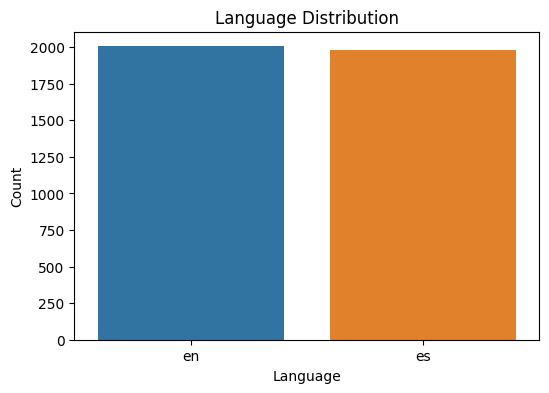

In [119]:
#Language distribution
print(df["lang"].value_counts(dropna=False))
plt.figure(figsize=(6, 4))
sns.barplot(x=df["lang"].value_counts().index, y=df["lang"].value_counts().values)
plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

In [120]:
df["text_length_chars"] = df["text"].fillna("").apply(len)
df["text_length_words"] = df["text"].fillna("").apply(lambda x: len(str(x).split()))
df[["text_length_chars", "text_length_words"]].describe()

,text_length_chars,text_length_words
count,3984.000000,3984.000000
mean,124.300452,21.595382
std,104.717776,18.115024
min,9.000000,2.000000
25%,64.000000,11.000000
50%,96.000000,17.000000
75%,144.000000,26.000000
max,1777.000000,299.000000


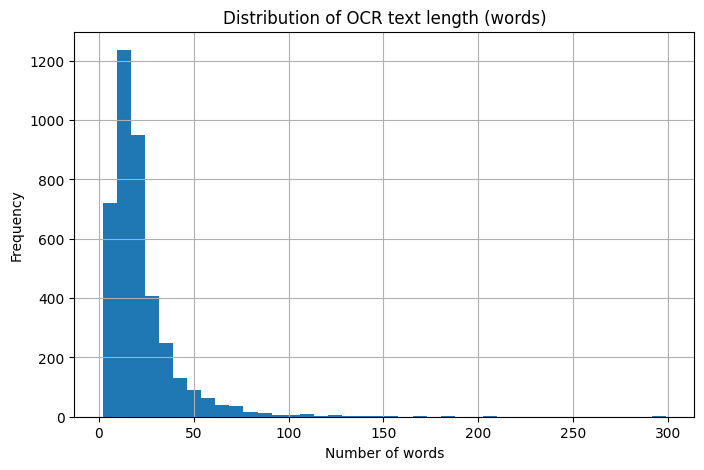

In [121]:
df["text_length_words"].hist(bins=40)
plt.title("Distribution of OCR text length (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

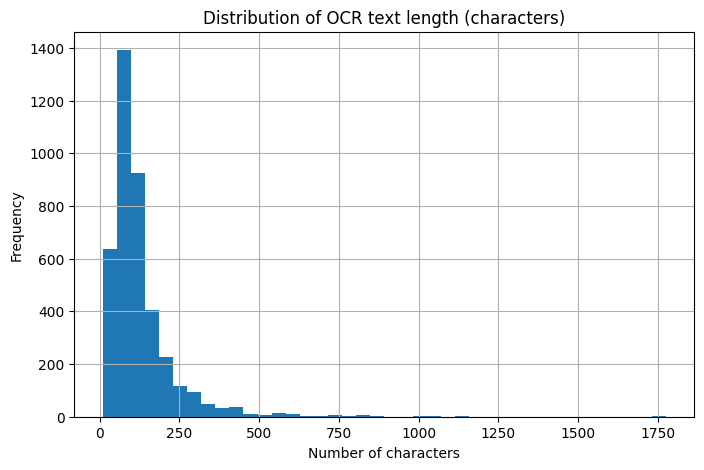

In [122]:
df["text_length_chars"].hist(bins=40)
plt.title("Distribution of OCR text length (characters)")
plt.xlabel("Number of characters")
plt.ylabel("Frequency")
plt.show()

### Label Distribution

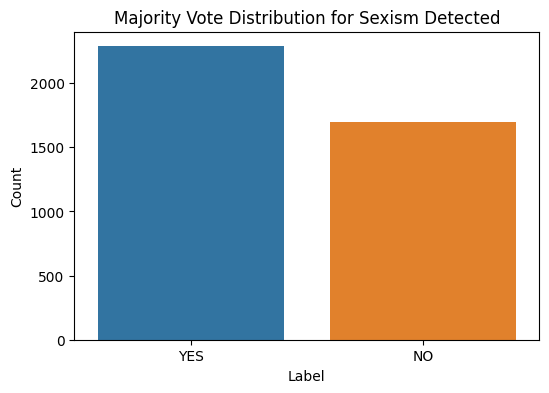

In [123]:
def remove_unknown(labels, unknown_values={"UNKNOWN"}):
    if not isinstance(labels, list):
        return []
    return [x for x in labels if x not in unknown_values]

def majority_vote(labels, unknown_values={"UNKNOWN"}):
    labels = remove_unknown(labels, unknown_values=unknown_values)
    if len(labels) == 0:
        return np.nan
    return Counter(labels).most_common(1)[0][0]


df["task2_1_mv"] = df["labels_task2_1"].apply(majority_vote)


plt.figure(figsize=(6, 4))
sns.countplot(x=df["task2_1_mv"])
plt.title("Majority Vote Distribution for Sexism Detected")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

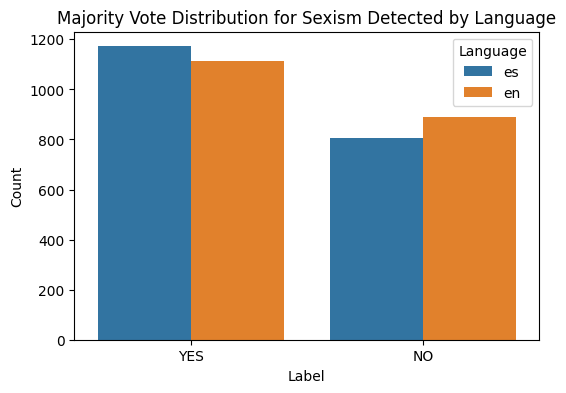

In [124]:
#Per Language
plt.figure(figsize=(6, 4))
sns.countplot(x=df["task2_1_mv"], hue=df["lang"])
plt.title("Majority Vote Distribution for Sexism Detected by Language")
plt.xlabel("Label")
plt.ylabel("Count")
plt.legend(title="Language")
plt.show()

In [125]:
#Agreement between annotators
def agreement_ratio(labels, unknown_values={"UNKNOWN"}):
    labels = remove_unknown(labels, unknown_values=unknown_values)
    if len(labels) == 0:
        return np.nan
    c = Counter(labels)
    return c.most_common(1)[0][1] / len(labels)

df["task2_1_agreement"] = df["labels_task2_1"].apply(agreement_ratio)
df["task2_1_agreement"].describe()

count    3984.000000
mean        0.771001
std         0.168078
min         0.500000
25%         0.666667
50%         0.833333
75%         0.833333
max         1.000000
Name: task2_1_agreement, dtype: float64

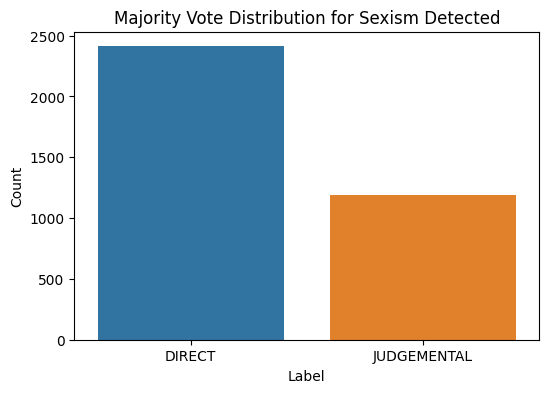

In [126]:
def majority_vote_task22(labels):
    if not isinstance(labels, list):
        return np.nan
    filtered = [x for x in labels if x not in {"UNKNOWN", "-"}]
    if len(filtered) == 0:
        return np.nan
    return Counter(filtered).most_common(1)[0][0]

df["task2_2_mv"] = df["labels_task2_2"].apply(majority_vote_task22)


plt.figure(figsize=(6, 4))
sns.countplot(x=df["task2_2_mv"])
plt.title("Majority Vote Distribution for Sexism Detected")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

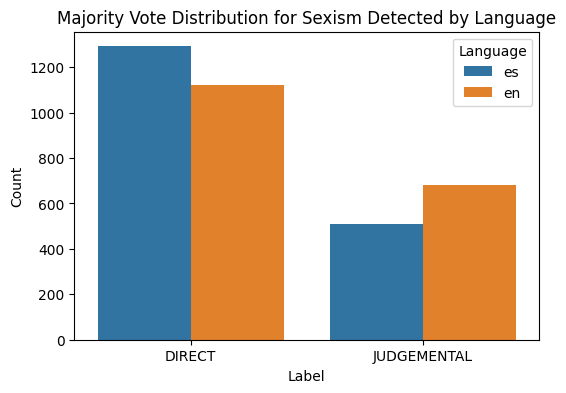

In [127]:
#Per Language
plt.figure(figsize=(6, 4))
sns.countplot(x=df["task2_2_mv"], hue=df["lang"])
plt.title("Majority Vote Distribution for Sexism Detected by Language")
plt.xlabel("Label")
plt.ylabel("Count")
plt.legend(title="Language")
plt.show()

In [128]:
#Agreement between annotators
df["task2_2_agreement"] = df["labels_task2_2"].apply(lambda x: agreement_ratio([y for y in x if y not in {"UNKNOWN", "-"}]) if isinstance(x, list) else np.nan)
df["task2_2_agreement"].describe()

count    3603.000000
mean        0.788283
std         0.188052
min         0.500000
25%         0.666667
50%         0.800000
75%         1.000000
max         1.000000
Name: task2_2_agreement, dtype: float64

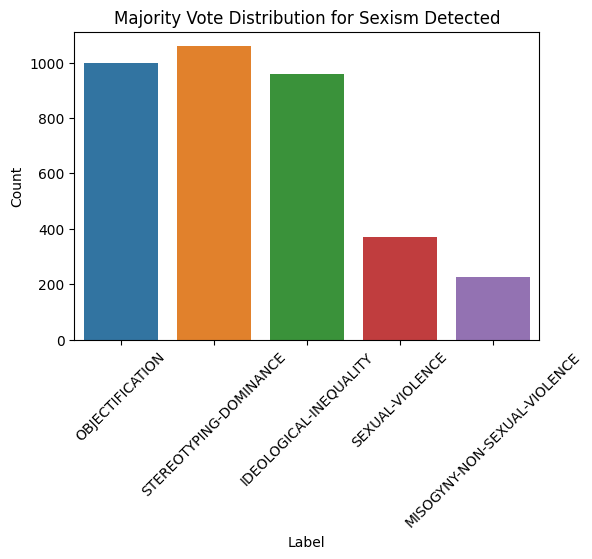

In [129]:
# Sexism Categorization 
def majority_vote_task23(labels):
    if not isinstance(labels, list):
        return np.nan

    flattened = []
    for x in labels:
        if isinstance(x, list):
            flattened.extend(x)
        else:
            flattened.append(x)

    filtered = [x for x in flattened if x not in {"UNKNOWN", "-"}]

    if len(filtered) == 0:
        return np.nan

    return Counter(filtered).most_common(1)[0][0]

df["task2_3_mv"] = df["labels_task2_3"].apply(majority_vote_task23)


plt.figure(figsize=(6, 4))
sns.countplot(x=df["task2_3_mv"])
plt.title("Majority Vote Distribution for Sexism Detected")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.show()

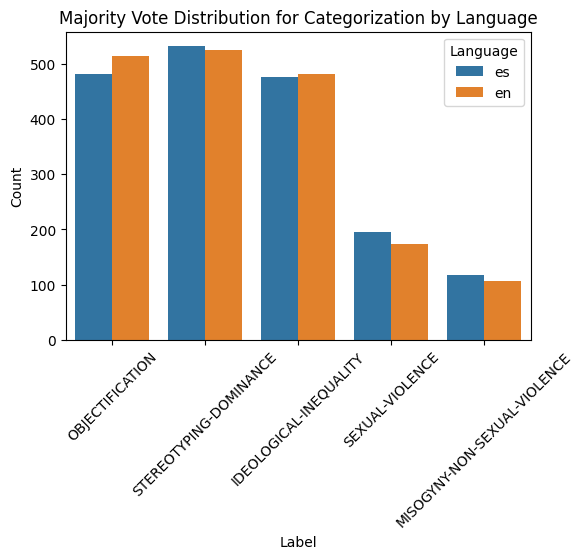

In [130]:
#Per Language
plt.figure(figsize=(6, 4))
sns.countplot(x=df["task2_3_mv"], hue=df["lang"])
plt.title("Majority Vote Distribution for Categorization by Language")
plt.xlabel("Label")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title="Language")
plt.show()

### Examples

In [131]:
def load_meme_image(row, images_dir=IMAGES_DIR):
    img_path = os.path.join(images_dir, row["meme"])
    if img_path is None:
        print(f"Image path is None for row: {row['id_EXIST']}")
        return None
    return Image.open(img_path)

def show_meme(row, images_dir=IMAGES_DIR, figsize=(8, 8)):
    img = load_meme_image(row, images_dir=images_dir)
    if img is None:
        return
    
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'id={row["id_EXIST"]} | lang={row["lang"]} | task2_1_mv={row.get("task2_1_mv", None)}\n'
              f'task2_2_mv={row.get("task2_2_mv", None)} | agreement={row.get("task2_1_agreement", None):.2f}')
    plt.show()
    
    print("Texto OCR:")
    print(row["text"])
    print("\nLabels task2.1:", row["labels_task2_1"])
    print("Labels task2.2:", row["labels_task2_2"])
    print("Labels task2.3:", row["labels_task2_3"])

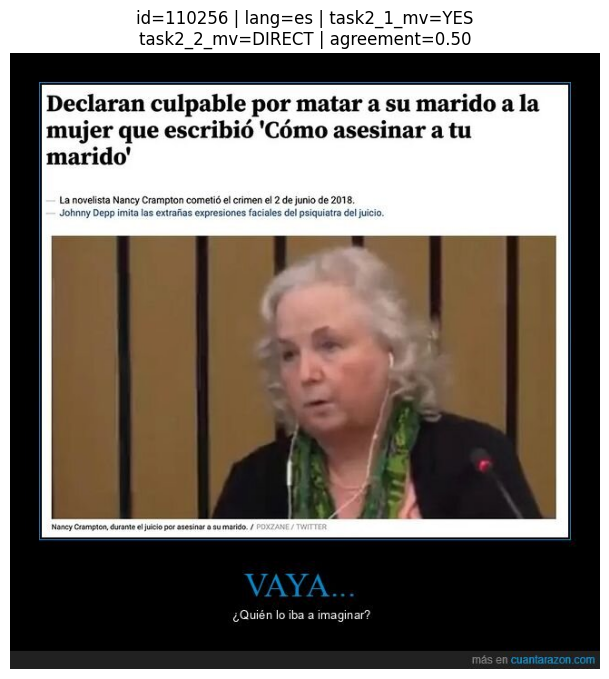

Texto OCR:
Declaran culpable por matar a su marido a la mujer que escribió 'Cómo asesinar a tu marido' La novelista Nancy Crampton cometió el crimen el 2 de junio de 2018. Johnny Depp imita las extrañas expresiones faciales del psiquiatra del juicio. Nancy Crampton, durante el juicio por asesinar a su marido. / PDXZANE/TWITTER VAYA... ¿Quién lo iba a imaginar? más en cuantarazon.com 

Labels task2.1: ['YES', 'YES', 'YES', 'NO', 'NO', 'NO']
Labels task2.2: ['DIRECT', 'DIRECT', 'DIRECT', '-', '-', '-']
Labels task2.3: [['IDEOLOGICAL-INEQUALITY'], ['IDEOLOGICAL-INEQUALITY'], ['STEREOTYPING-DOMINANCE'], ['-'], ['-'], ['-']]


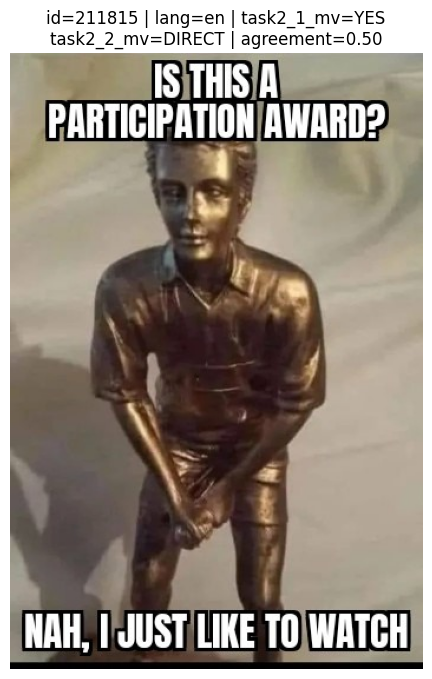

Texto OCR:
IS THIS A PARTICIPATION AWARD? NAH, I JUST LIKE TO WATCH  

Labels task2.1: ['YES', 'NO', 'NO', 'NO', 'YES', 'YES']
Labels task2.2: ['JUDGEMENTAL', '-', '-', '-', 'DIRECT', 'DIRECT']
Labels task2.3: [['SEXUAL-VIOLENCE'], ['-'], ['-'], ['-'], ['SEXUAL-VIOLENCE', 'MISOGYNY-NON-SEXUAL-VIOLENCE'], ['STEREOTYPING-DOMINANCE']]


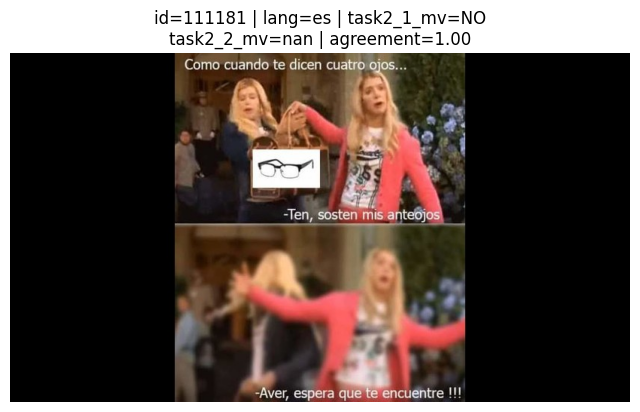

Texto OCR:
Como cuando te dicen cuatro ojos... -Ten, sosten mis anteojos -Aver, espera que te encuentre !!! 

Labels task2.1: ['NO', 'NO', 'NO', 'NO', 'NO', 'NO']
Labels task2.2: ['-', '-', '-', '-', '-', '-']
Labels task2.3: [['-'], ['-'], ['-'], ['-'], ['-'], ['-']]


In [132]:
sample_rows = df.sample(3, random_state=42)
for _, row in sample_rows.iterrows():
    show_meme(row)

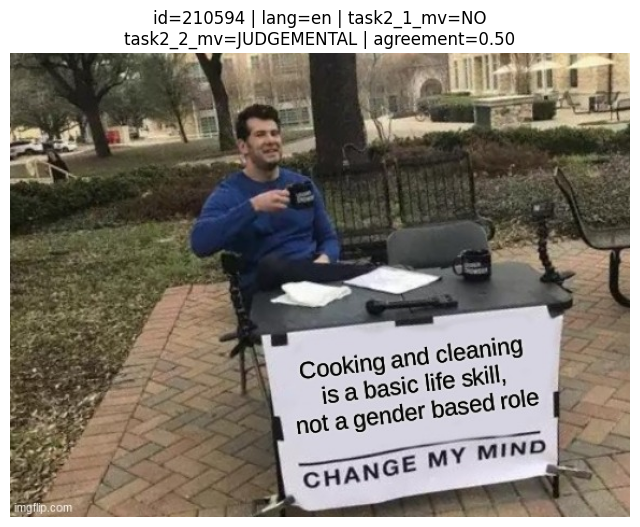

Texto OCR:
imgflip.com Cooking and cleaning is a basic life skill, not a gender based role CHANGE MY MIND  

Labels task2.1: ['NO', 'YES', 'YES', 'NO', 'YES', 'NO']
Labels task2.2: ['-', 'DIRECT', 'JUDGEMENTAL', '-', 'JUDGEMENTAL', '-']
Labels task2.3: [['-'], ['IDEOLOGICAL-INEQUALITY'], ['STEREOTYPING-DOMINANCE'], ['-'], ['STEREOTYPING-DOMINANCE'], ['-']]


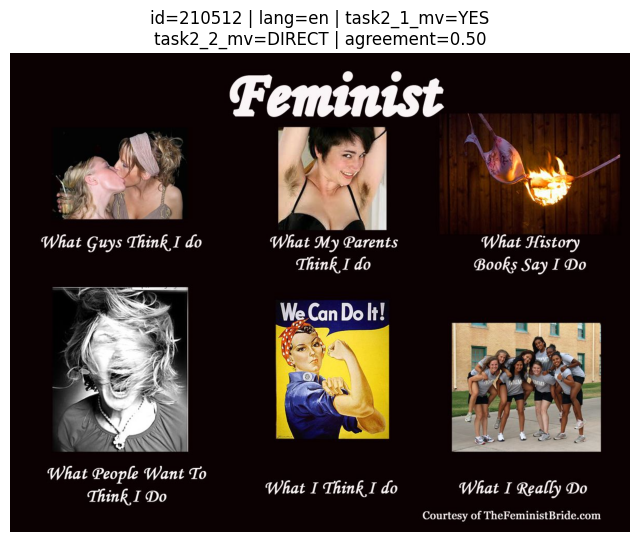

Texto OCR:
What Guys Think I do What People Want To Think I Do Feminist What My Parents Think I do We Can Do It! What I Think I do What History Books Say I Do MM What I Really Do Courtesy of TheFeministBride.com  

Labels task2.1: ['YES', 'NO', 'NO', 'NO', 'YES', 'YES']
Labels task2.2: ['JUDGEMENTAL', '-', '-', '-', 'DIRECT', 'DIRECT']
Labels task2.3: [['IDEOLOGICAL-INEQUALITY', 'STEREOTYPING-DOMINANCE'], ['-'], ['-'], ['-'], ['STEREOTYPING-DOMINANCE'], ['IDEOLOGICAL-INEQUALITY']]


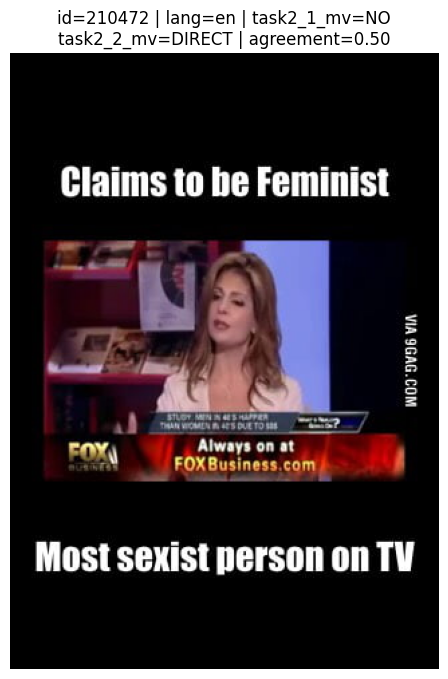

Texto OCR:
Claims to be Feminist FOX STUDT MEN IN 45 HAPPER THAN WOMEN 4S DUE TO Always on at FOXBusiness.com VIA 9GAG.COM Most sexist person on TV  

Labels task2.1: ['NO', 'NO', 'YES', 'YES', 'NO', 'YES']
Labels task2.2: ['-', '-', 'DIRECT', 'DIRECT', '-', 'JUDGEMENTAL']
Labels task2.3: [['-'], ['-'], ['IDEOLOGICAL-INEQUALITY'], ['MISOGYNY-NON-SEXUAL-VIOLENCE'], ['-'], ['IDEOLOGICAL-INEQUALITY', 'OBJECTIFICATION']]


In [133]:
# Ambiguous cases with low agreement
ambiguous = df.sort_values("task2_1_agreement").head(3)
for _, row in ambiguous.iterrows():
    show_meme(row)

### Sensorial Data

In [134]:
df["has_sensorial"] = df["sensorial"].apply(lambda x: isinstance(x, dict))
df["has_sensorial"].value_counts(dropna=False)

True    3984
Name: has_sensorial, dtype: int64

In [135]:
df["sensorial_num_users"] = df["sensorial"].apply(lambda x: len(x.get("users", [])) if isinstance(x, dict) else 0)
df["sensorial_num_users"].value_counts().sort_index()

2      18
3     423
4    3543
Name: sensorial_num_users, dtype: int64

In [136]:
# Aggregate heart rate features 
def aggregate_hr(sensorial):
    result = {
        "hr_mean_mean": np.nan,
        "hr_std_mean": np.nan,
        "hr_min_mean": np.nan,
        "hr_max_mean": np.nan}
    
    if not isinstance(sensorial, dict):
        return result
    
    try:
        by_user = sensorial["modalities"]["HR"]["by_user"]
        if len(by_user) == 0:
            return result
        
        hr_mean = []
        hr_std = []
        hr_min = []
        hr_max = []
        
        for _, vals in by_user.items():
            hr_mean.append(vals.get("garmin_hr_mean", np.nan))
            hr_std.append(vals.get("garmin_hr_std", np.nan))
            hr_min.append(vals.get("garmin_hr_min", np.nan))
            hr_max.append(vals.get("garmin_hr_max", np.nan))
        
        result = {
            "hr_mean_mean": np.nanmean(hr_mean),
            "hr_std_mean": np.nanmean(hr_std),
            "hr_min_mean": np.nanmean(hr_min),
            "hr_max_mean": np.nanmean(hr_max)}
        return result
    
    except Exception:
        return result
    
hr_df = pd.DataFrame(df["sensorial"].apply(aggregate_hr).tolist())
df = pd.concat([df, hr_df], axis=1)
df[["hr_mean_mean", "hr_std_mean", "hr_min_mean", "hr_max_mean"]].head()

,hr_mean_mean,hr_std_mean,hr_min_mean,hr_max_mean
0,62.63795,1.293100,60.839050,64.626750
1,59.74850,1.467133,57.333333,61.666667
2,64.20835,0.640100,63.500000,65.000000
3,68.33260,1.681800,65.676350,70.384450
4,71.16665,0.934300,70.000000,72.500000


In [137]:
def aggregate_et(sensorial):
    result = {
        "et_reaction_time_mean": np.nan,
        "et_fixations_count_mean": np.nan,
        "et_saccades_count_mean": np.nan,
        "et_blinks_count_mean": np.nan
    }

    if not isinstance(sensorial, dict):
        return result

    modalities = sensorial.get("modalities", {})
    et_block = modalities.get("ET", {})
    by_user = et_block.get("by_user", {})

    if not isinstance(by_user, dict) or len(by_user) == 0:
        return result

    reaction_time = []
    fix_count = []
    sacc_count = []
    blink_count = []

    for user, vals in by_user.items():
        if not isinstance(vals, dict):
            continue

        reaction_time.append(vals.get("reaction_time", np.nan))
        fix_count.append(vals.get("fixations_count", np.nan))
        sacc_count.append(vals.get("saccades_count", np.nan))
        blink_count.append(vals.get("blinks_count", np.nan))

    def safe_nanmean(values):
        arr = pd.to_numeric(pd.Series(values), errors="coerce").dropna()
        return arr.mean() if len(arr) > 0 else np.nan

    return {
        "et_reaction_time_mean": safe_nanmean(reaction_time),
        "et_fixations_count_mean": safe_nanmean(fix_count),
        "et_saccades_count_mean": safe_nanmean(sacc_count),
        "et_blinks_count_mean": safe_nanmean(blink_count)
    }
    
et_df = pd.DataFrame(df["sensorial"].apply(aggregate_et).tolist())
df = pd.concat([df, et_df], axis=1)
df[["et_reaction_time_mean", "et_fixations_count_mean", "et_saccades_count_mean", "et_blinks_count_mean"]].head()

,et_reaction_time_mean,et_fixations_count_mean,et_saccades_count_mean,et_blinks_count_mean
0,13394.00295,42.92820,42.65420,2.36100
1,14951.00000,48.00000,47.00000,2.00000
2,11928.33335,40.33335,39.66665,1.66665
3,10587.17535,31.90805,30.90805,1.80810
4,6142.00000,19.00000,19.00000,NaN


In [144]:
#Is there any any difference in these features between sexist and non-sexist memes?
df.groupby("task2_1_mv")[["hr_mean_mean", "et_reaction_time_mean", "et_fixations_count_mean"]].mean()

,hr_mean_mean,et_reaction_time_mean,et_fixations_count_mean
task2_1_mv,,,
NO,69.469815,13810.305067,40.348524
YES,69.434359,15508.803967,43.764741


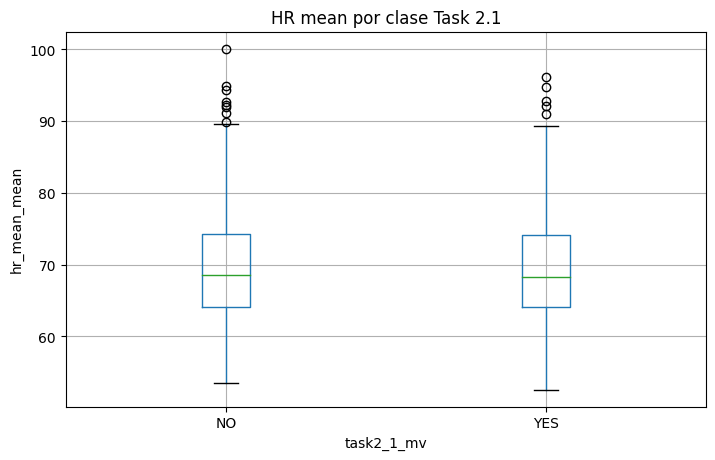

In [141]:
df.boxplot(column="hr_mean_mean", by="task2_1_mv")
plt.title("HR mean por clase Task 2.1")
plt.suptitle("")
plt.xlabel("task2_1_mv")
plt.ylabel("hr_mean_mean")
plt.show()

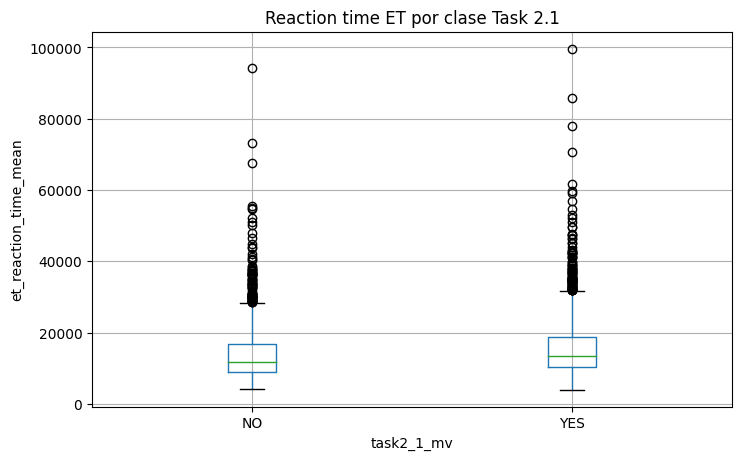

In [143]:
df.boxplot(column="et_reaction_time_mean", by="task2_1_mv")
plt.title("Reaction time ET por clase Task 2.1")
plt.suptitle("")
plt.xlabel("task2_1_mv")
plt.ylabel("et_reaction_time_mean")
plt.show()